# **Tutorial: Radial Gridded Image Reconstruction & Motion Gating**
---


Created by Dr Nicholas Senn, AMT Center, University of Aberdeen

Originally created for the Advanced Chest MRI School, Aberdeen, Septemeber 2026

Email: nicholas.senn2@abdn.ac.uk

Github page: https://github.com/nicholas-senn/teaching-resources/tree/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image%20Reconstruction%20and%20Motion%20Gating

Developed as part of the V|LF-Spiro3D project: https://v-lf-spiro3d.eu/

-----------------------------------------------------------

This material is provided for educational and research purposes only.
It is not intended for clinical use.

© Nicholas Senn, 2026.
Released under the MIT Licence.

The software is provided "as is", without warranty of any kind.

-----------------------------------------------------------

## About This Tutorial

This tutorial is designed to demonstrate the principles of non-Cartesian MRI reconstruction, self-navigation, amplitude gating and phase-portrait gating.

The notebook contains Python code that performs the image reconstruction and motion-sorting steps. **It is not necessary to understand any of the code in order to achieve the learning objectives of this tutorial.**

The primary learning objectives are to understand:

- How a kooshball acquisition samples k-space.
- Why non-Cartesian image reconstruction requires gridding.
- How self-navigation signals can be extracted from radial MRI data.
- How amplitude gating can be used to reduce motion blurring.
- Why amplitude gating has limitations.
- How phase-portrait analysis can separate different stages of a motion cycle.

Participants who are interested in the implementation details are encouraged to explore the code cells and function definitions. However, the tutorial can be completed successfully by focusing on the figures, results and discussion questions provided throughout the notebook.

⚠️ **Computational Warning**

Three-dimensional non-Cartesian image reconstruction is computationally demanding. Depending on your computer hardware and software environment, some reconstruction steps may take several minutes to complete. A complete execution of the notebook may take approximately 10-15 minutes, depending on the hardware available.

**To ensure that all participants can complete the tutorial regardless of computing resources, all figures and outputs have been pre-populated within the notebook. Running the code is therefore not required to achieve the learning objectives of the tutorial.**

Participants are encouraged to execute the code if time and computing resources permit, but it is equally acceptable to follow the tutorial using the provided figures and accompanying PDF document.

# **Introduction**

## **Background**

During every breath, the lungs expand, contract and change shape as air moves through the respiratory system.

Many important measurements of lung function depend on understanding this motion. By imaging the lungs throughout the breathing cycle, it is possible to investigate regional ventilation, lung expansion, diaphragm motion and other physiological processes that are difficult to assess using static imaging alone.

The challenge is that acquiring MRI data that captures the entire whole 3D lung volume and breathing cycle takes many minutes, with longer scan times needed to achieve higher image resolution. During this time the lungs move through multiple respiratory cycles. When images of the lung are reconstructed from the acquired MRI data, the breathing states are combined together, the resulting image becomes blurred and information about lung motion is lost.

To image lung function effectively, we therefore need methods that can both track respiratory motion and separate data acquired during different stages of the breathing cycle.

## **Why Use Radial Imaging?**

Because every spoke passes through the centre of k-space, radial imaging provides both image information and motion information within the same acquisition.

In this tutorial, a three-dimensional centre-out radial sampling strategy, often referred to as a **kooshball trajectory**, was used to acquire the MRI k-space data. Unlike conventional Cartesian MRI, every radial spoke passes through the centre of k-space. This repeated sampling of the k-space centre provides a motion-sensitive signal that can be used to track respiratory motion directly from the acquired data. This process is commonly known as **self-navigation**.

Self-navigation removes the need for external respiratory monitoring devices and allows motion information to be extracted directly from the MRI acquisition.

## **Why Are Special Reconstruction Methods Required?**

Although radial imaging provides useful motion information, it introduces a new challenge.

Conventional MRI data are sampled on a Cartesian grid and can be reconstructed directly using a Fourier transform. In contrast, kooshball trajectories sample k-space along radial spokes. Before image reconstruction can be performed, these non-Cartesian samples must first be interpolated onto a Cartesian lattice using a process known as **gridding**.

Understanding this reconstruction process forms the first part of this tutorial.

## **Why Is Gating Needed?**

The self-navigation signal obtained from the centre of k-space provides information about the motion state of the lungs throughout the acquisition. This information can be used to group data acquired during similar stages of the breathing cycle before reconstruction.

The simplest approach is **amplitude gating**, where data are selected according to the amplitude of the motion signal. This reduces motion blurring by reconstructing only data acquired at similar positions. It can be used as a motion correction strategy.

However, amplitude alone does not uniquely define a breathing state. The same position can occur during both inhalation and exhalation. To separate these states, the direction of motion must also be considered. This is achieved using a **phase portrait**, which combines motion amplitude and temporal derivative to describe the state of the motion cycle more completely. Using this approach, data can be sorted into multiple motion states, allowing reconstruction of a sequence of images, fully seperating different stages of the breathing cycle, including inhalatio and exhalation.

Understanding these gating processes forms the second part of this tutorial.

# **Learning Objectives**

By the end of this tutorial you will be able to:


*   Visualise a three-dimensional kooshball MRI trajectory.
*   Reconstruct non-Cartesian MRI data using gridding.
*   Understand the effect of undersampling on image quality.
*   Extract a self-navigation signal from the centre of k-space.
*   Apply amplitude gating to reduce motion blurring.
*   Understand the limitations of amplitude-based gating.
*   Construct and interpret a phase portrait.
*   Sort data into multiple motion states.
*   Reconstruct motion-resolved images that can be used to study lung function.

In [3]:
# Set up

import numpy as np
import matplotlib.pyplot as plt


import os
import urllib.request
from scipy.io import loadmat
from scipy.interpolate import griddata
from scipy.fft import ifftn, fftshift, ifftshift

import time
from IPython.display import Image, display


def download_dataset(url, filename):

# Downloaded data to the current working directory of the notebook:
# print(os.getcwd())

    # Check whether the dataset has already been downloaded.
    # If the file already exists locally, it does not need
    # to be downloaded again.
    if not os.path.exists(filename):

        print(f"Downloading {filename}...")

        # Download the dataset from the GitHub Release URL
        # and save it using the specified filename.
        urllib.request.urlretrieve(
            url,
            filename
        )

        print("Download complete")

    else:

        # Reuse the existing file if it is already present.
        print(f"{filename} already exists")

    # Return the local filename so that it can be passed
    # directly to loadmat() or other file-loading functions.
    return filename

def download_dataset(url, filename):

    if not os.path.exists(filename):

        print(f"Downloading {filename}...")

        urllib.request.urlretrieve(
            url,
            filename
        )

        print("Download complete")

    else:

        print(f"{filename} already exists")

    return filename

# **The Data**

Our goal at the AMT Centre, University of Aberdeen, is to develop very low-field MRI technologies that address important unmet healthcare needs. As part of the V|LF-Spiro3D project, we have been investigating how advanced whole-lung functional MRI techniques can be translated and adapted to operate under the hardware constraints imposed by very low-field systems. Our long-term objective is to enable quantitative lung function imaging on emerging very low-field scanners, helping to address one of the greatest challenges in medical imaging: improving access to advanced diagnostic technologies.

This tutorial makes use of a moving phantom data set acquired using a very low-field MRI system. The data consists of a limited number of acquired radial spokes which reduces the demand on computational resources needed to complete the image reconstruction steps.

Imaging experiments were performed using an extremity, resistive and unshielded biplanar scanner at 0.1 T with a single channel solenoid transmit/receive coil tuned at 4.252 MHz. Data was collected from a test phantom object (Figure 1) using a 3D unbalanced gradient echo sequence.The phantom was either static or manually displaced ± 9 mm with period of approximately 5 seconds during acquisition.  

*The following parameters were used to acquire the data: 50,000 centre-out radial trajectories, TE/TR = 3/15 ms, number of readout points = 96, voxel size = [1.5 × 1.5 × 1.5] mm<sup>3</sup>, bandwidth = 25 kHz, flip angle = 30 °, number of averages (NA) = 1. For this first implementation, the 50,000 trajectories were split into blocks of 1,000 spokes to meet the memory conditions of the spectrometer (Cameleon 3, RS2D).*  

*The order of acquired radial trajectories was randomised before acquisition to avoid introducing periodic patterns of DC signal and in turn error to retrospective motion state gating as observed when ordered trajectories are used (Figure 2). The pre-phase gradient was adjusted to ensure that the peak of each free induction decay (FID) signal was acquired, and each FID peak was shifted to first readout point in post postprocessing. The 30 spokes acquired at start of each block were not included in image reconstruction due to loss of steady state (see Figure 1).*


**Data set 1:** 7000 spoke subset of data acquired with phanton stationary.
**Data set 2:** 48500 spoke data set with phantom moving.
Each data set contains a trajectory file of X,Y,Z coordinates of k-space radial spoke end points, and acquired FID of each radial spoke.



Download complete


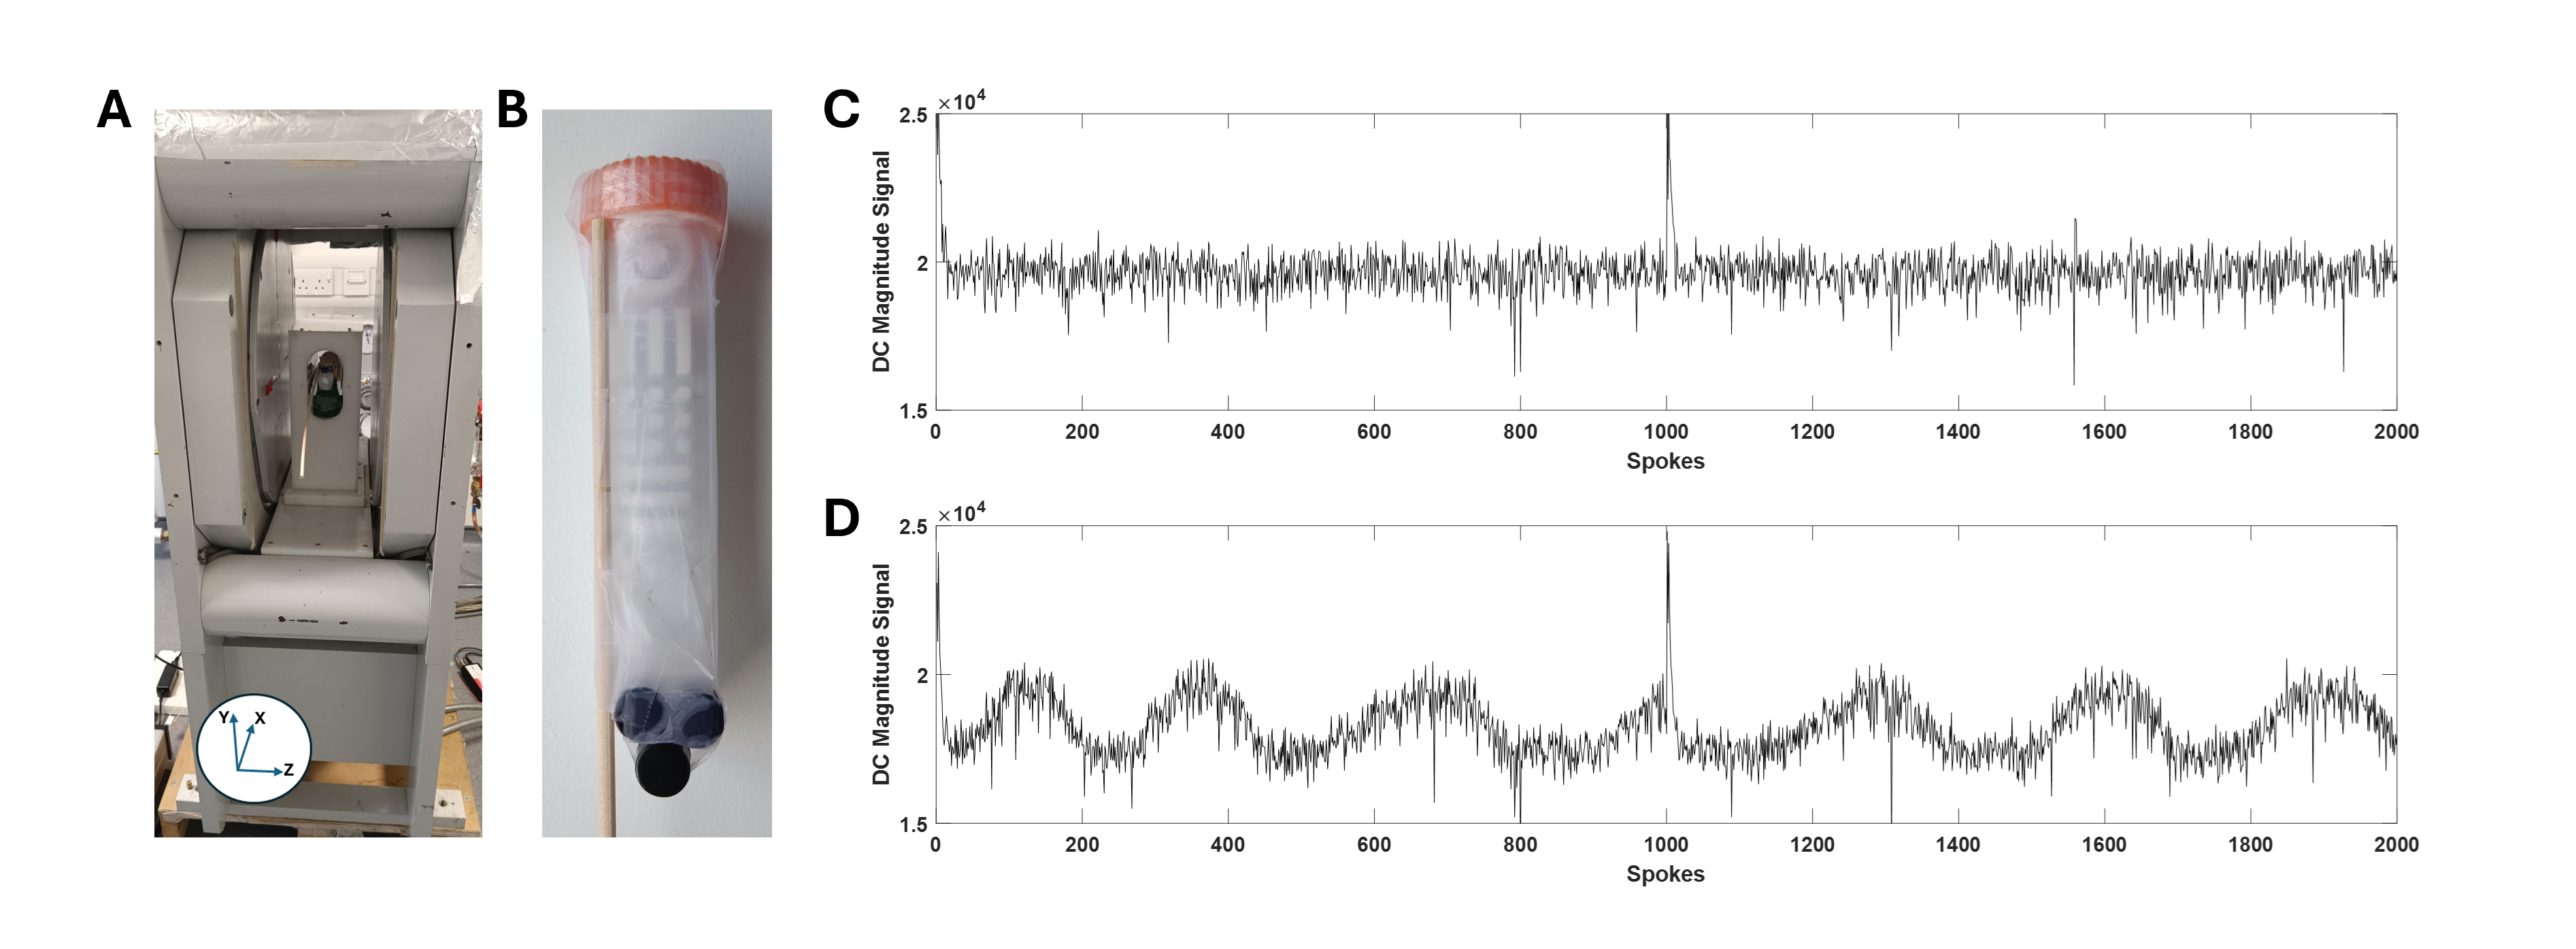


**Figure 1.** **A:** Extremity-sized, bi-planar MRI scanner operating at 0.1 T.
**B:** Test phantom consisting of a 3D-printed structure housed within a 50 mL Falcon tube and three vertical vials.
All compartments contained 0.5 mM MnCl<sub>2</sub> solution.
**C:** Magnitude DC signal acquired across 2,000 radial spokes with the phantom stationary.
**D:** Magnitude DC signal acquired while the phantom was displaced by ±9 mm along the x-axis with a motion period of approximately 5 s.


In [4]:
# Download and display Figure 1

figure1_url = (
    "https://raw.githubusercontent.com/nicholas-senn/teaching-resources/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image%20Reconstruction%20and%20Motion%20Gating/Figures/figure1.png"
)

download_dataset(
    figure1_url,
    "figure1.png"
)

from IPython.display import Image, display, Markdown

display(Image("figure1.png"))

display(Markdown(
"""
**Figure 1.** **A:** Extremity-sized, bi-planar MRI scanner operating at 0.1 T.
**B:** Test phantom consisting of a 3D-printed structure housed within a 50 mL Falcon tube and three vertical vials.
All compartments contained 0.5 mM MnCl<sub>2</sub> solution.
**C:** Magnitude DC signal acquired across 2,000 radial spokes with the phantom stationary.
**D:** Magnitude DC signal acquired while the phantom was displaced by ±9 mm along the x-axis with a motion period of approximately 5 s.
"""
))

In [5]:
# Load the data sets from https://github.com/nicholas-senn/teaching-resources/releases/tag/v1.0

stationary_url = (
    "https://github.com/nicholas-senn/teaching-resources/releases/download/v1.0/data_stationary_small.mat"
)

download_dataset(
    stationary_url,
    "data_stationary_small.mat"
)

mat = loadmat(
    "data_stationary_small.mat"
)

data = mat["dataRad"]
trajectory = mat["trajectoryXYZ"]

print("Data Set 1 K-space data shape:", data.shape)
print("Data Set 1 trajectory shape:", trajectory.shape)

moving_url = (
    "https://github.com/nicholas-senn/teaching-resources/releases/download/v1.0/data_moving.mat"
)

download_dataset(
    moving_url,
    "data_moving.mat"
)

mat = loadmat(
    "data_moving.mat"
)

data_moving = mat["dataRad"]
trajectory_moving = mat["trajectoryXYZ"]

print("Data Set 2 (moving) K-space data shape:", data_moving.shape)
print("Data Set 2 (moving) trajectory shape:", trajectory_moving.shape)

Download complete
Data Set 1 K-space data shape: (96, 7500)
Data Set 1 trajectory shape: (7500, 3)
Download complete
Data Set 2 (moving) K-space data shape: (96, 48500)
Data Set 2 (moving) trajectory shape: (48500, 3)


# Tutorial 1

## Objectives

1. Reconstruct non-Cartesian MRI data using gridding.
2. Investigate the effect of undersampling on image quality.

## Gridding Reconstruction

The kooshball acquisition samples MRI data along radial spokes rather than on a regular Cartesian grid. Because the data are acquired on a non-Cartesian trajectory, they cannot be reconstructed directly using a Fourier transform.

Image reconstruction therefore consists of three main steps:

1. Calculate the three-dimensional k-space coordinates of every acquired sample.
2. Interpolate the non-Cartesian samples onto a regular Cartesian k-space grid (gridding).
3. Apply a three-dimensional inverse Fourier transform to reconstruct the image.

The reconstruction process can be summarised as:

**Kooshball MRI Data → Determine k-space Coordinates → Grid onto Cartesian k-space → 3D Inverse Fourier Transform → Reconstructed Image**

The same reconstruction pipeline will be used throughout this tutorial. Later sections will explore how selecting different subsets of spokes can be used to investigate undersampling, perform amplitude gating and separate different motion states using phase-based sorting.

In [6]:
# Define functions for image reconstruciton from kooshball data sets and image visualisaiton.

def reconstruct_kooshball(
        data,
        trajectory,
        n_spokes = None,
        recon_matrix=192):

# Parameters
#
# data
#   Complex MRI FID data with dimensions:
#   [readout_samples, spokes]
#
# trajectory
#   K-space end-point coordinates for each spoke with
#   dimensions [spokes, 3] corresponding to x, y and z.
#
# n_spokes
#   Number of spokes to use for reconstruction.
#   If None, all available spokes are used.
#
# recon_matrix
#   Number of Cartesian k-space samples used along each
#   dimension of the reconstruction grid.
#
#   Example:
#       recon_matrix = 192
#
#   creates a 192 × 192 × 192 Cartesian k-space grid and
#   produces a 192 × 192 × 192 voxel image following the
#   inverse Fourier transform.
#
#   Increasing recon_matrix generates a finer voxel grid
#   and a higher-resolution image representation but does
#   not create additional information.
#
# Returns
#
# image
#   Magnitude reconstructed 3D image volume.


    # Use a subset of spokes if requested.
    # This allows the effects of undersampling to be investigated.
    if n_spokes is not None:
        data = data[:, :n_spokes]
        trajectory = trajectory[:n_spokes, :]

    # Determine the number of readout samples and spokes.
    n_readout, n_spokes = data.shape

    print(f"Reconstructing using {n_spokes:,} spokes")

    # Pre-allocate arrays containing the x, y and z k-space
    # coordinates of every acquired sample.
    X = np.zeros(n_readout * n_spokes)
    Y = np.zeros(n_readout * n_spokes)
    Z = np.zeros(n_readout * n_spokes)

    # Pre-allocate array containing the complex MRI signal
    # associated with each k-space coordinate.
    V = np.zeros(
        n_readout * n_spokes,
        dtype=np.complex128
    )

    # The first readout sample is acquired during the first
    # dwell period rather than exactly at k = 0. Therefore,
    # sample positions are placed at the centre of each dwell.
    t = (np.arange(n_readout) + 0.5) / n_readout

    px = 0

    # Generate the k-space coordinates of every acquired sample.
    # Each radial spoke extends from the centre of k-space to
    # the trajectory end point.
    for i in range(n_spokes):

        xt = trajectory[i, 0]
        yt = trajectory[i, 1]
        zt = trajectory[i, 2]

        # Calculate x, y and z coordinates along the spoke.
        X[px:px+n_readout] = xt * t
        Y[px:px+n_readout] = yt * t
        Z[px:px+n_readout] = zt * t

        # Store the corresponding complex MRI signal.
        V[px:px+n_readout] = data[:, i]

        px += n_readout

    # Determine the maximum sampled k-space radius and define
    # the Cartesian reconstruction grid.
    kmax = np.max(np.abs(trajectory))

    grid_axis = np.linspace(
        -kmax,
        kmax,
        recon_matrix
    )

    # Create a three-dimensional Cartesian k-space lattice.
    xq, yq, zq = np.meshgrid(
        grid_axis,
        grid_axis,
        grid_axis,
        indexing='ij'
    )

    # Grid the non-Cartesian radial samples onto the Cartesian
    # lattice using linear interpolation.
    vq = griddata(
        (X, Y, Z),
        V,
        (xq, yq, zq),
        method='linear',
        fill_value=0
    )

    # Once the data occupy a Cartesian grid, a 3D inverse
    # Fourier transform can be used to reconstruct the image.
    image = fftshift(
        ifftn(
            ifftshift(vq)
        )
    )

    # Return the magnitude image.
    return np.abs(image)



def show_image(image, title, offset=5):

    cy = image.shape[1] // 2 + offset

    vmax = np.percentile(image, 99.9) * 1.5

    plt.figure(figsize=(8,8))

    plt.imshow(
        image[:, cy, :],
        cmap='gray',
        origin='lower',
        vmin=0,
        vmax=vmax
    )

    plt.title(title)
    plt.axis('off')

    plt.show()



def compare_image(images, titles, offset=+5):

    n = len(images)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for ax, image, title in zip(axes, images, titles):

        cy = image.shape[1] // 2 + offset

        vmax = np.percentile(image, 99.9) * 1.5

        ax.imshow(
            image[:, cy, :],
            cmap='gray',
            origin='lower',
            vmin=0,
            vmax=vmax
        )

        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Reconstructing the Stationary Phantom

Before investigating motion, we first reconstruct images from the stationary phantom dataset.

The same reconstruction method will be used throughout the tutorial; only the number of spokes included in the reconstruction will change.

To investigate the effects of undersampling, reconstruct the phantom using:

- 1,000 spokes
- 4,000 spokes
- 7,000 spokes

As the number of spokes increases, k-space becomes more densely sampled and more information is available for image reconstruction.

Compare the resulting images and consider the following questions:

- How does image quality change as the number of spokes increases?
- What artefacts are visible when only 1,000 spokes are used?
- At what point does the structure of the phantom become clearly visible?
- Does increasing the number of spokes improve image quality more than increasing the reconstruction matrix size?

The aim of this section is to understand the relationship between k-space sampling density and image quality before introducing motion into the acquisition.


 ⚠️ **Computational Warning**

Image reconstruction is the most computationally demanding part of this tutorial. The gridding step interpolates non-Cartesian MRI data onto a three-dimensional Cartesian k-space lattice before reconstruction can be performed.

Depending on your computer hardware, and if using Google Colab Runtime, each reconstruction may take several minutes to complete.

A PDF version of this tutorial containing all expected outputs is available, allowing you to continue following the tutorial while reconstructions are running.

Reconstructing using 7,000 spokes
Reconstructing using 1,000 spokes
Reconstructing using 4,000 spokes


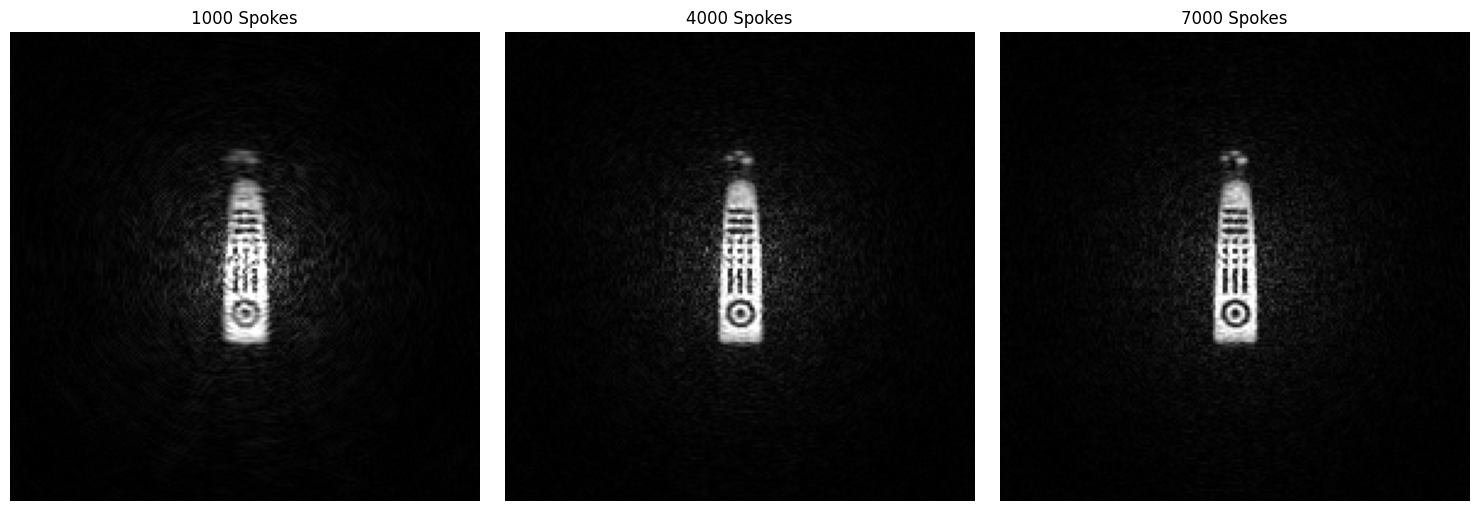

In [7]:
image_7000 = reconstruct_kooshball(
        data,
        trajectory,7000)

image_1000 = reconstruct_kooshball(
    data,
    trajectory,
    n_spokes=1000
)

image_4000 = reconstruct_kooshball(
    data,
    trajectory,
    n_spokes=4000
)

compare_image(
    [image_1000, image_4000, image_7000],
    ['1000 Spokes', '4000 Spokes', '7000 Spokes']
)


# Tutorial 2: Amplitude Motion Gating

## Objectives

1. Understand effect of moving on image reconstruction without gating
2. Extract a self-navigation signal from the centre of k-space.
3. Apply amplitude gating to reduce motion blurring.
4. Understand the limitations of amplitude-based gating.

## Why Is Gating Needed?

In Tutorial 1, images were reconstructed from a stationary phantom. In this case, every spoke represents the same object position and can therefore be combined during reconstruction.

Lung imaging is fundamentally different because the lungs move continuously throughout the MRI acquisition. If data acquired at different stages of the breathing cycle are reconstructed together, information from multiple motion states is combined, resulting in image blurring and loss of spatial detail.

A key advantage of the kooshball trajectory is that every spoke passes through the centre of k-space. These repeated measurements of the k-space centre can be used to generate a self-navigation signal that tracks motion throughout the acquisition.

Before introducing gating, we first reconstruct the moving phantom dataset using all acquired spokes. This provides a reference image showing the effects of motion when no motion correction strategy is applied.

The same reconstruction pipeline used in Tutorial 1 will be used throughout the remainder of the tutorial. The only difference is which spokes are included in the reconstruction.

# Moving Phantom No Gating

Reconstructing using 7,000 spokes


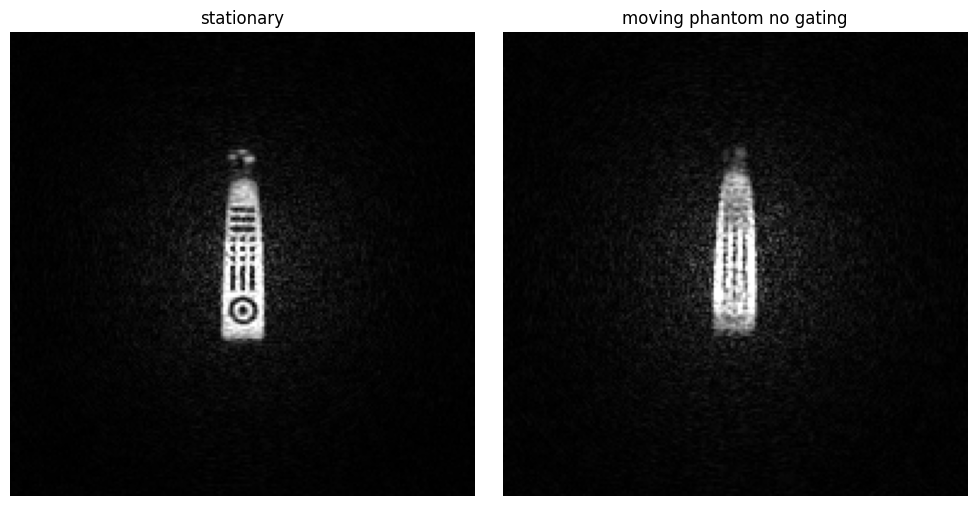

In [8]:
image_moving_no_gating = reconstruct_kooshball(
        data_moving,
        trajectory_moving,7000)

compare_image(
    [image_7000,image_moving_no_gating],
    ['stationary','moving phantom no gating']
)

## Amplitude-Gated Reconstruction

The amplitude-gating windows defined above identify groups of spokes acquired when the phantom occupied similar positions during its motion cycle.

The simplest way to use this information is to reconstruct an image using only the spokes contained within a selected amplitude range. By excluding data acquired at other motion states, the range of object positions contributing to the reconstruction is reduced.

This approach can reduce motion blurring because fewer motion states are combined within a single image. However, there is a trade-off. Selecting only a subset of spokes also reduces the amount of k-space data available for reconstruction, which can increase undersampling artefacts.

For each gating window:

1. Spokes whose self-navigation signal falls within the specified amplitude range are selected.
2. The corresponding k-space trajectories are extracted.
3. The selected spoke subset is reconstructed using the same gridding reconstruction pipeline developed in Tutorial 1.

The reconstruction algorithm itself is unchanged. The only difference is the subset of spokes included in the reconstruction.

**Moving MRI Data > Self-Navigation Signal > Amplitude Gate > Select Matching Spokes > Gridding Reconstruction > Amplitude-Gated Image**

In [9]:
# Define functons needed for amplitude gating and visualising the gates

# Amplitude gating assumes that spokes acquired at similar
# motion amplitudes correspond to similar motion states.


def create_amplitude_gate(signal, lower_threshold, upper_threshold):

    # Create a Boolean mask identifying all spokes whose
    # self-navigation signal lies within the specified
    # amplitude range.
    gate_mask = (
        (signal >= lower_threshold) &
        (signal <= upper_threshold)
    )

    # Report how many spokes have been selected and the
    # percentage of the acquisition retained.
    print(f"Selected spokes: {np.sum(gate_mask)}")
    print(f"Percentage retained: {100*np.mean(gate_mask):.1f}%")

    return gate_mask


def show_amplitude_gates(signal, threshold_ranges):

    # Display only a representative section of the motion
    # signal to improve visualisation.
    start_spoke = 2000
    end_spoke = 8000

    plt.figure(figsize=(12,4))

    # Plot the filtered and normalised self-navigation signal.
    plt.plot(
        signal,
        color='black',
        linewidth=1.5,
        label='Filtered Respiratory Signal'
    )

    # Colours used to display different gating windows.
    colors = ['red', 'blue', 'green', 'orange', 'purple']

    # Overlay the amplitude-gating windows as shaded bands.
    for i, (lower, upper) in enumerate(threshold_ranges):

        plt.axhspan(
            lower,
            upper,
            alpha=0.2,
            color=colors[i % len(colors)],
            label=f'{lower:.2f}-{upper:.2f}'
        )

    # Determine display limits using only the visible
    # section of the signal.
    y_min = np.min(signal[start_spoke:end_spoke])
    y_max = np.max(signal[start_spoke:end_spoke])

    # Add a small padding to improve readability.
    padding = 0.05 * (y_max - y_min)

    plt.xlim(start_spoke, end_spoke)
    plt.ylim(y_min - padding, y_max + padding)

    plt.xlabel('Spoke Number')
    plt.ylabel('Normalised Signal')
    plt.title('Amplitude Gating Windows')

    plt.grid(True)
    plt.show()

# Extract the first readout point as the navigator signal, filter it, and overlay three amplitude threshold mask regions.

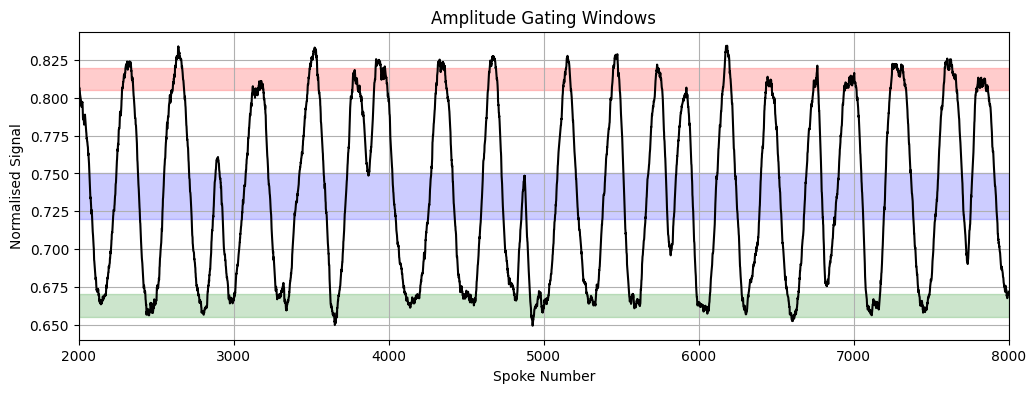

In [10]:
# Extract the magnitude of the first readout sample from every
# radial spoke. Because each spoke passes through the centre of
# k-space, this signal is sensitive to phantom motion and can
# be used as a self-navigation signal.
navigator = np.abs(data_moving[0, :])

# Moving-average filter width.
# Increasing the window size produces a smoother motion signal
# but may reduce temporal resolution.
window = 50

# Apply a moving-average filter to suppress noise and
# emphasise the underlying motion pattern.
filtered = np.convolve(
    navigator,
    np.ones(window) / window,
    mode='same'
)

# Calculate global minimum and maximum values across both
# the original and filtered signals. Using the same scaling
# allows the two signals to be compared directly.
signal_min = min(
    navigator.min(),
    filtered.min()
)

signal_max = max(
    navigator.max(),
    filtered.max()
)

# Normalise the original self-navigation signal to the range [0,1].
navigator_norm = (
    navigator - signal_min
) / (signal_max - signal_min)

# Normalise the filtered self-navigation signal using the
# same scale. This signal will be used for motion gating.
filtered_norm = (
    filtered - signal_min
) / (signal_max - signal_min)

# Display the selected amplitude-gating windows.
# Each shaded band represents a range of motion amplitudes
# that will be used to select spokes for reconstruction.
show_amplitude_gates(
    filtered_norm,
    [
        (0.805, 0.82),
        (0.72, 0.75),
        (0.655, 0.67)
    ]
)

# Amplitude gated image reconstruction

*   Create the masks needed to extract (gate) the radial spokes that have DC signal within the threshold limits.
*   Reconstruct the gated images using the masked radial spokes only.
*   Create images for each gated image reconstruciton.

# Questions to consider


1.   Does image sharpness improve when using gating?
2.   How does the appearance change between different amplitude windows?
3.   Do all gating windows contain the same number of spokes?
4.   What would happen to the image quality if a narrower gate width was used?
5.   What trade-off exists between motion reduction and undersampling?



Selected spokes: 6142
Percentage retained: 12.7%
Reconstructing using 6,142 spokes
Selected spokes: 5094
Percentage retained: 10.5%
Reconstructing using 5,094 spokes
Selected spokes: 8714
Percentage retained: 18.0%
Reconstructing using 8,714 spokes


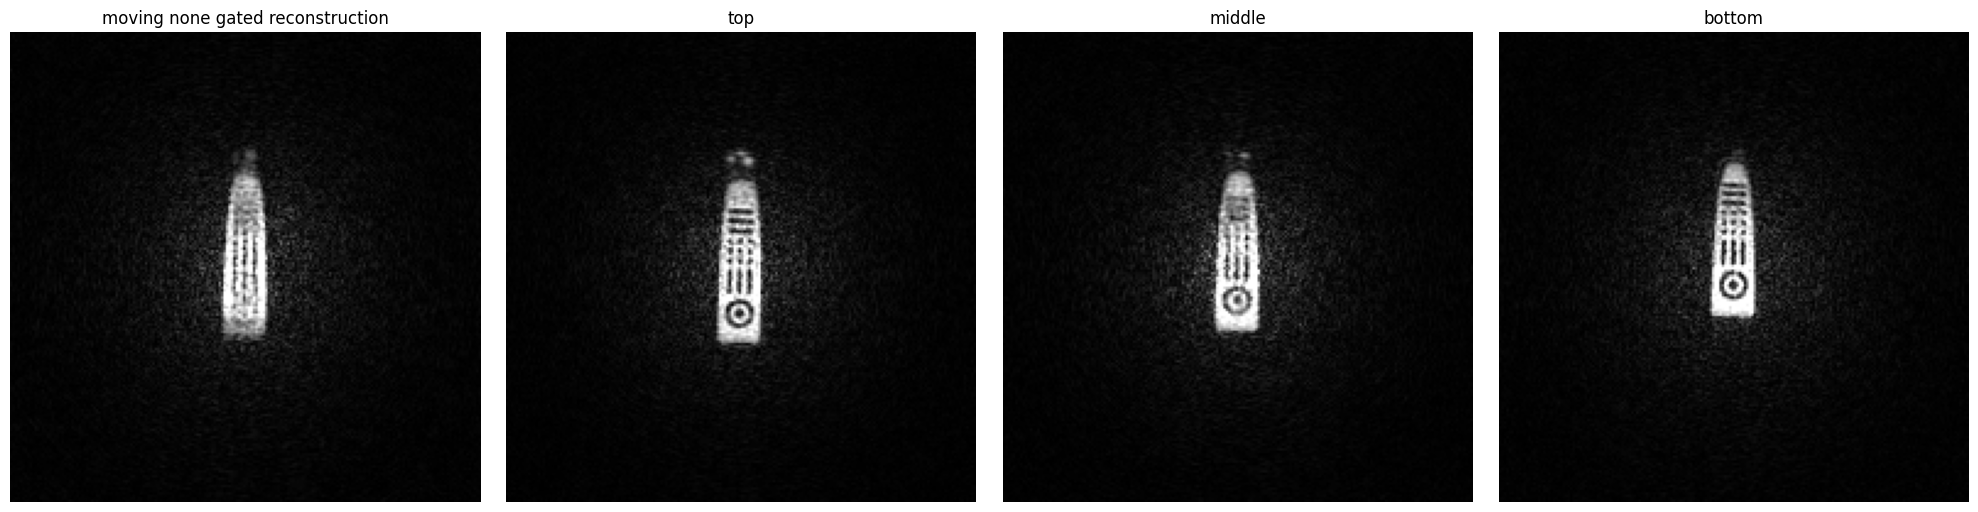

In [11]:

gate_mask = create_amplitude_gate(filtered_norm, lower_threshold=0.805, upper_threshold=0.82)
data_gated = data_moving[:, gate_mask]
trajectory_gated = trajectory_moving[gate_mask, :]
image_top = reconstruct_kooshball(data_gated,trajectory_gated,recon_matrix=192)

gate_mask = create_amplitude_gate(filtered_norm, lower_threshold=0.72, upper_threshold=0.75)
data_gated = data_moving[:, gate_mask]
trajectory_gated = trajectory_moving[gate_mask, :]
image_middle = reconstruct_kooshball(data_gated,trajectory_gated,recon_matrix=192)

gate_mask = create_amplitude_gate(filtered_norm, lower_threshold=0.655, upper_threshold=0.67)
data_gated = data_moving[:, gate_mask]
trajectory_gated = trajectory_moving[gate_mask, :]
image_bottom = reconstruct_kooshball(data_gated,trajectory_gated,recon_matrix=192)

compare_image(
    [image_moving_no_gating, image_top, image_middle, image_bottom],
    ['moving none gated reconstruction','top', 'middle', 'bottom']
)



# Tutorial 3: Phase Portrait Gating

## Objectives

1. Understand the limitations of amplitude gating.
2. Construct a phase portrait from the self-navigation signal.
3. Separate identical amplitudes undergoing motion in opposite directions.
4. Reconstruct motion-resolved images representing different stages of the motion cycle.

## Why Is Amplitude Gating Not Enough?

In Tutorial 2, image reconstruction was performed by selecting spokes whose self-navigation signal fell within a specified amplitude range.

This approach assumes that all spokes acquired at a particular amplitude correspond to the same motion state. However, this is not always true.

Consider a phantom moving backwards and forwards. During each motion cycle, the phantom passes through the same position twice:

- Once while moving in the positive direction.
- Once while moving in the negative direction.

Although these two states have the same amplitude, they represent physically different motion conditions.

Amplitude gating cannot distinguish between them and therefore combines data acquired while the object is moving in opposite directions.

As a result, amplitude gating can still mix motion states and may not completely remove motion artefacts.

For lung function imaging, it is often desirable to separate inhalation and exhalation into distinct phases of the breathing cycle. Amplitude gating alone cannot achieve this because the same lung position may occur during both inhalation and exhalation. To distinguish between these states, information about the direction of motion must also be incorporated into the gating process.

## What Is a Phase Portrait?

To separate these motion states, information about the direction of motion must be included.

A phase portrait is constructed by plotting:

- The motion signal amplitude (x-axis).
- The temporal derivative of the motion signal (y-axis).

# Step 1: Create the phase protrait graph depicting all self-navigation points

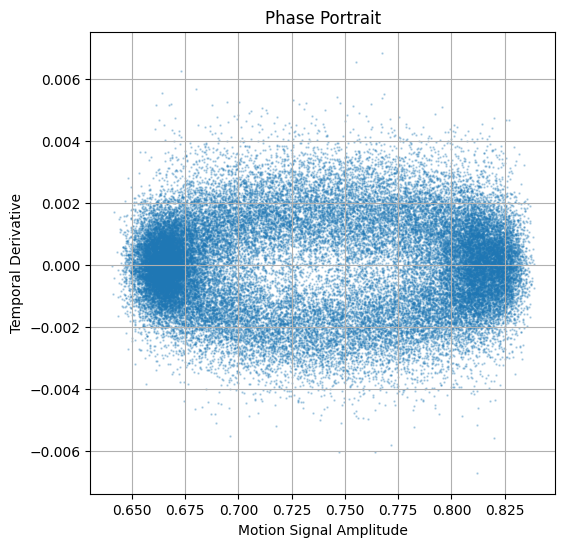

In [12]:
# Exclude the first and last 50 samples. These points
# can be affected by edge effects introduced by the
# moving-average filter and may produce unreliable
# derivative estimates.
resp = filtered_norm[50:-50]

# Calculate the temporal derivative of the motion signal.
# The derivative provides information about the direction
# of motion and how rapidly the object is moving.
resp_dot = np.gradient(resp)

# Create a square figure for displaying the phase portrait.
plt.figure(figsize=(6,6))

# Construct the phase portrait by plotting the motion
# signal amplitude (x-axis) against its derivative
# (y-axis). Each point represents a single acquired spoke.
plt.scatter(
    resp,
    resp_dot,
    s=0.5,
    alpha=0.3
)

# Label axes and add a title.
plt.xlabel('Motion Signal Amplitude')
plt.ylabel('Temporal Derivative')
plt.title('Phase Portrait')

# Add grid lines to aid interpretation.
plt.grid(True)

# Display the figure.
plt.show()

# Step 2. Compare how the amplitude gates overlay with the phase portrait

- Look at the blue band. The amplitude gating covers the cycle of moving the phantom backwards and forwards.

- Think about how you could use the phase portrait graph to create gating masks that seperate the movement cycle.

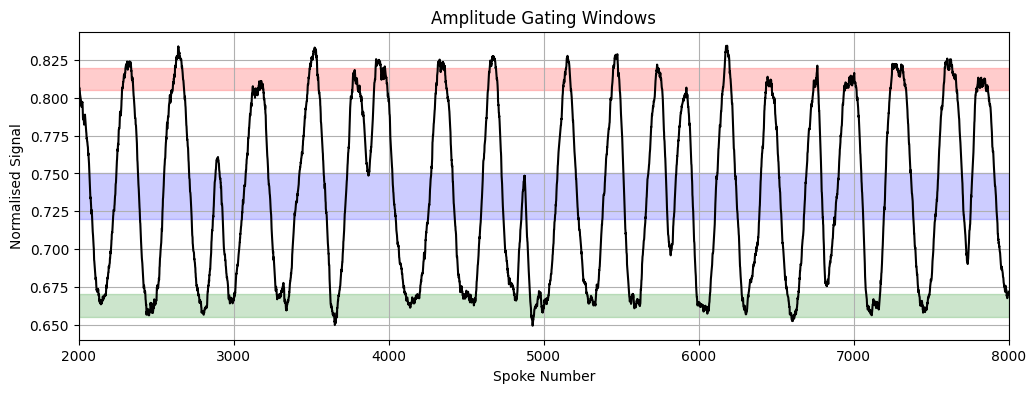

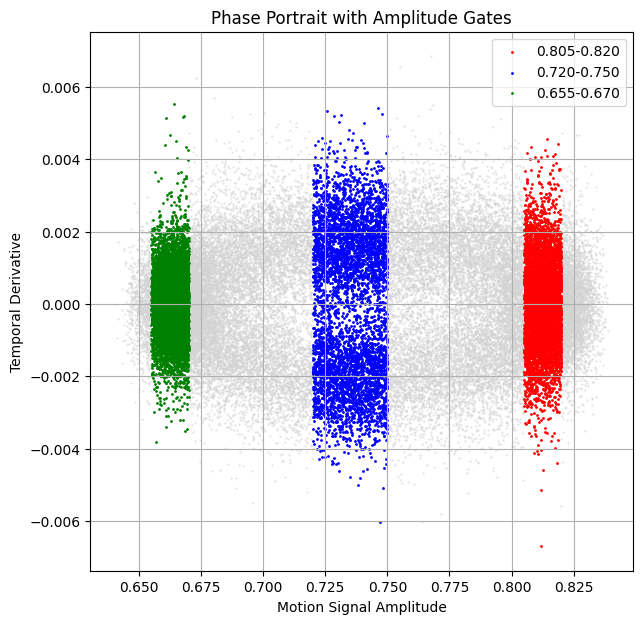

In [13]:

# Display the amplitude-gating windows used in Tutorial 2.
show_amplitude_gates(
    filtered_norm,
    [
        (0.805, 0.82),
        (0.72, 0.75),
        (0.655, 0.67)
    ]
)

# Amplitude-gating thresholds used in the previous section.
thresholds = [
    (0.805, 0.82),
    (0.72, 0.75),
    (0.655, 0.67)
]

# Use the same colours as the amplitude-gating figure.
colors = ['red', 'blue', 'green']

plt.figure(figsize=(7,7))

# Plot all points in the phase portrait.
plt.scatter(
    resp,
    resp_dot,
    s=0.5,
    color='lightgray',
    alpha=0.5
)

# Overlay the amplitude-gated spokes.
for (lower, upper), color in zip(thresholds, colors):

    mask = (
        (resp >= lower) &
        (resp <= upper)
    )

    plt.scatter(
        resp[mask],
        resp_dot[mask],
        s=1,
        color=color,
        label=f'{lower:.3f}-{upper:.3f}'
    )

plt.xlabel('Motion Signal Amplitude')
plt.ylabel('Temporal Derivative')
plt.title('Phase Portrait with Amplitude Gates')

plt.legend()
plt.grid(True)

plt.show()

The amplitude gates used in Tutorial 2 are now overlaid on
the phase portrait. Notice that each amplitude range selects
two separate regions of the phase portrait. These correspond
to the same motion amplitude being reached while moving in
opposite directions. Amplitude gating therefore mixes
multiple motion states within a single reconstruction.

In [14]:
# Divide the phase portrait into equally populated motion states,
# allowing reconstruction of multiple stages of the motion cycle.


def create_phase_bins(resp, resp_dot, n_bins=8, edge=50):

    # Total number of spokes in the acquisition.
    n = len(resp)

    # Create a mask identifying spokes that will be excluded
    # from phase analysis. Samples near the start and end of
    # the acquisition are omitted because derivative estimates
    # are less reliable in these regions.
    excluded_mask = np.ones(n, dtype=bool)
    excluded_mask[edge:-edge] = False

    # Use only the central portion of the motion signal when
    # constructing the phase portrait.
    x = resp[edge:-edge]
    y = resp_dot[edge:-edge]

    # Centre the phase portrait about the origin.
    # This simplifies the calculation of the phase angle.
    x = x - np.mean(x)
    y = y - np.mean(y)

    # Calculate the phase angle of every point in the
    # phase portrait.
    #
    # arctan2() returns angles between -π and π.
    # The modulo operation converts these to the range
    # 0 to 2π, representing one complete motion cycle.
    theta = np.mod(np.arctan2(y, x), 2*np.pi)

    # Divide the phase angles into equally populated bins.
    # Each bin therefore contains approximately the same
    # number of spokes.
    phase_edges = np.quantile(
        theta,
        np.linspace(0, 1, n_bins + 1)
    )

    phase_masks = []

    print(
        f'Excluded spokes: {np.sum(excluded_mask)}'
    )

    # Generate a Boolean mask for each phase bin.
    for i in range(n_bins):

        # Identify points whose phase angle lies within
        # the current bin.
        if i == n_bins - 1:
            mask_crop = (
                (theta >= phase_edges[i]) &
                (theta <= phase_edges[i + 1])
            )
        else:
            mask_crop = (
                (theta >= phase_edges[i]) &
                (theta < phase_edges[i + 1])
            )

        # Expand the mask back to the full acquisition
        # length so that it can be applied directly to
        # the original MRI data and trajectory arrays.
        mask_full = np.zeros(n, dtype=bool)
        mask_full[edge:-edge] = mask_crop

        phase_masks.append(mask_full)

        print(
            f'Bin {i+1}: '
            f'{np.sum(mask_full)} spokes'
        )

    # Return the phase-bin masks and the mask of
    # excluded spokes.
    return phase_masks, excluded_mask


# Step 3. Use the phase gating method create 8 masks covering the moving cylce and visualise  

- Which part of the phase portrait correponds to which part of the moving cycle?

- This method forces the gate mask bins to contain an equal number of spokes to ensure there are enough spokes to reduce extent of undersampling for the image reconstruction. Can you think of alternative ways to create the gates? Is there a way to create the gates with equal time intervals across the moving cycle?

Excluded spokes: 100
Bin 1: 6050 spokes
Bin 2: 6050 spokes
Bin 3: 6050 spokes
Bin 4: 6050 spokes
Bin 5: 6050 spokes
Bin 6: 6050 spokes
Bin 7: 6050 spokes
Bin 8: 6050 spokes


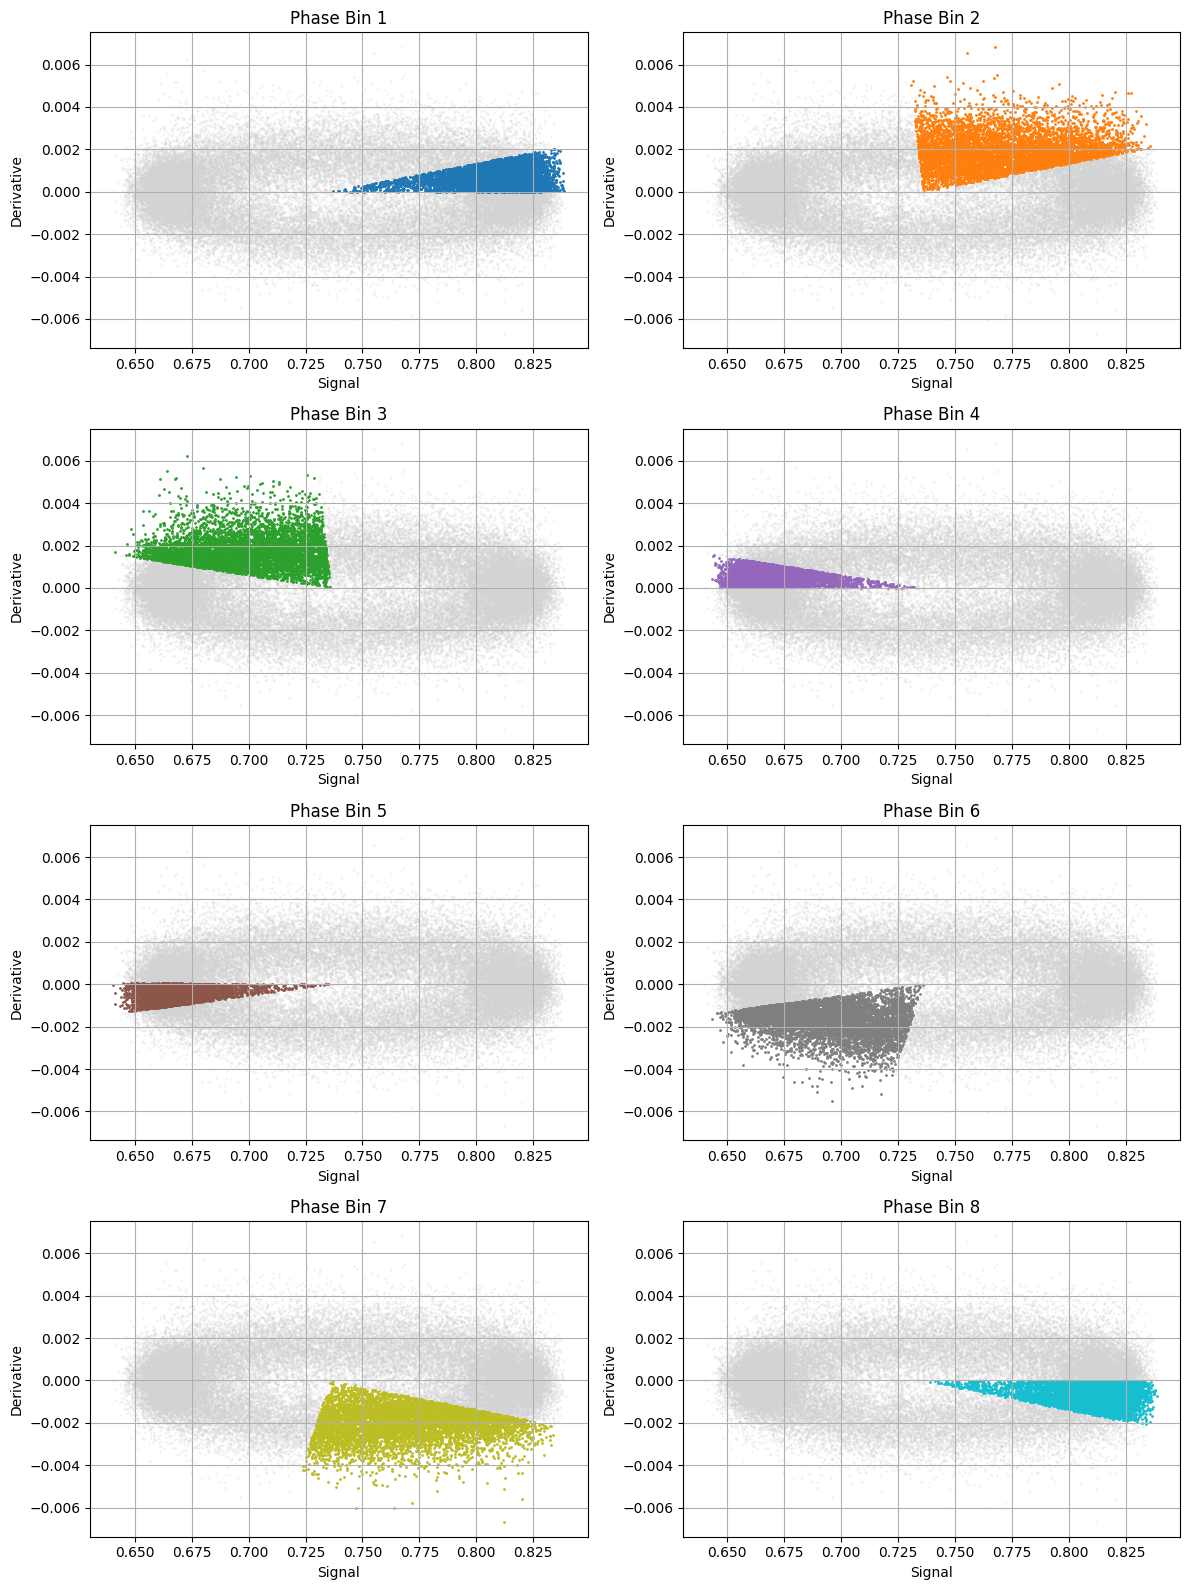

In [15]:
# Divide the phase portrait into eight equally populated bins.
# Each bin represents a different stage of the motion cycle and
# will later be reconstructed as a separate motion state.

# Use the filtered and normalised self-navigation signal
# as the input for phase-portrait analysis.
resp = filtered_norm

# Calculate the temporal derivative of the motion signal.
# The derivative provides information about the direction
# and speed of motion.
resp_dot = np.gradient(resp)

# Exclude samples at the start and end of the acquisition.
# These points can be affected by filter edge effects and
# produce unreliable phase estimates.
edge = 50

# Divide the phase portrait into eight equally populated
# phase bins and identify excluded spokes.
phase_masks, excluded_mask = create_phase_bins(
    filtered_norm,
    resp_dot,
    n_bins=8,
    edge=edge
)

# Create cropped versions of the phase portrait for display.
resp_plot = resp[edge:-edge]
resp_dot_plot = resp_dot[edge:-edge]

# Generate a colour map to display the phase bins.
colors = plt.cm.tab10(
    np.linspace(0, 1, len(phase_masks))
)

# Create a figure showing all eight phase bins.
fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

axes = axes.ravel()

for i in range(8):

    ax = axes[i]

    # Display the complete phase portrait in grey.
    ax.scatter(
        resp_plot,
        resp_dot_plot,
        s=1,
        color='lightgrey',
        alpha=0.2
    )

    # Extract the current phase bin and remove the
    # excluded edge samples for plotting.
    mask_plot = phase_masks[i][edge:-edge]

    # Highlight the spokes assigned to the current phase bin.
    ax.scatter(
        resp_plot[mask_plot],
        resp_dot_plot[mask_plot],
        s=1,
        color=colors[i]
    )

    ax.set_title(f'Phase Bin {i+1}')
    ax.set_xlabel('Signal')
    ax.set_ylabel('Derivative')
    ax.grid(True)

plt.tight_layout()
plt.show()


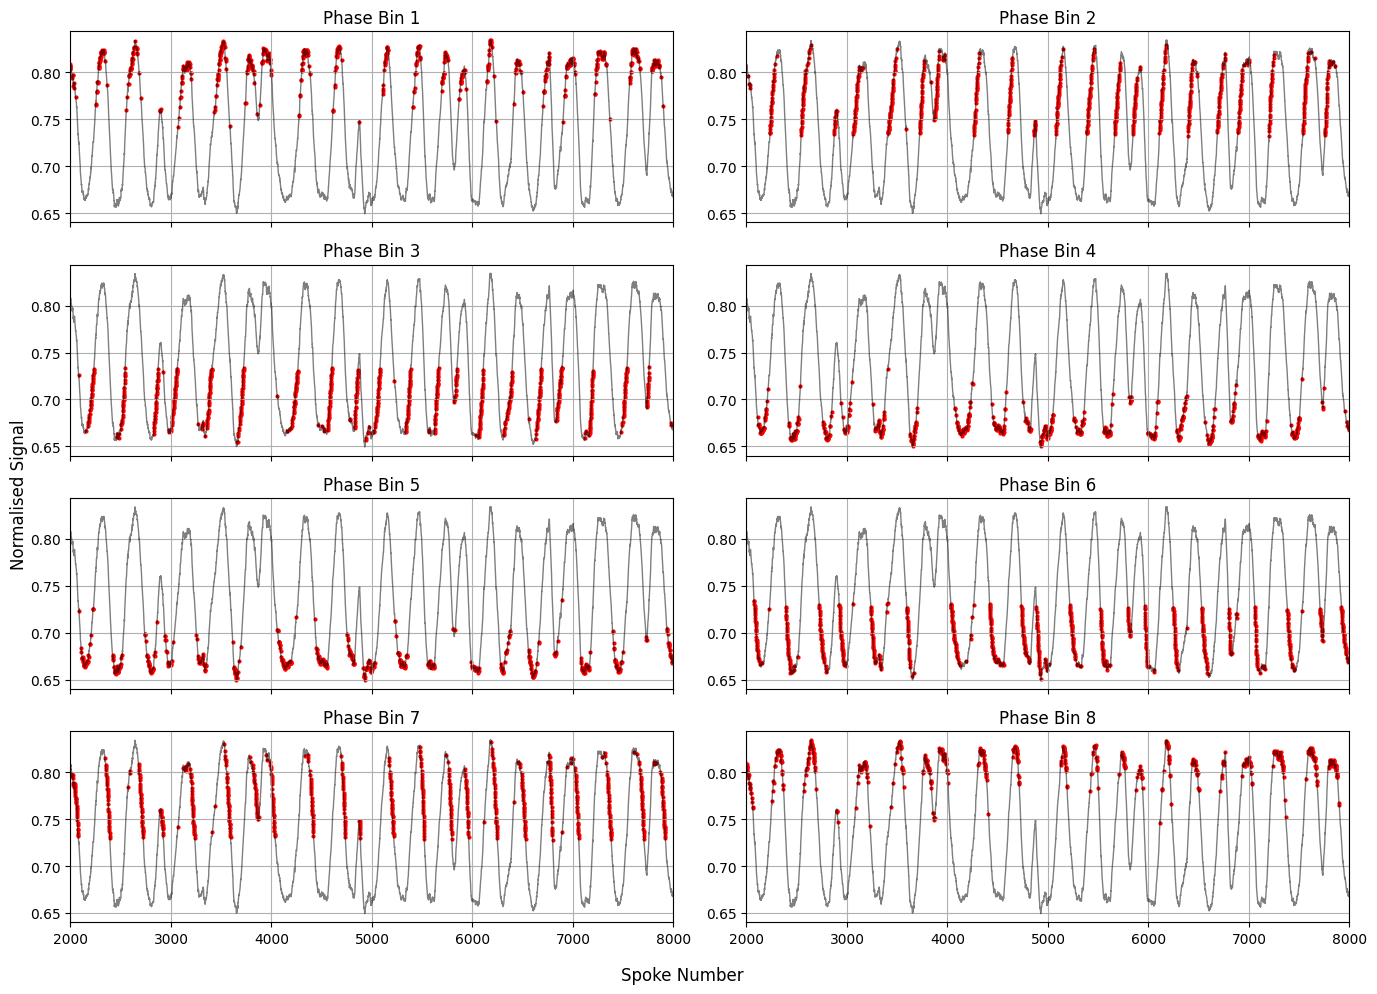

In [16]:
# Visualise where each phase bin lies within the motion signal.
# Notice that a single phase bin selects data from multiple
# motion cycles but from the same stage of motion.

# Display only a representative section of the motion signal.
# This makes the phase bins easier to visualise.
start_spoke = 2000
end_spoke = 8000

# Create a figure containing one subplot for each phase bin.
# The eight subplots correspond to the eight motion states
# identified from the phase portrait.
fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 10),
    sharex=True
)

axes = axes.ravel()

for bin_idx in range(8):

    ax = axes[bin_idx]

    # Plot the complete self-navigation signal in grey.
    # This provides a reference showing the full motion cycle.
    ax.plot(
        filtered_norm,
        color='black',
        linewidth=1,
        alpha=0.5
    )

    # Extract the spokes assigned to the current phase bin.
    mask = phase_masks[bin_idx]

    # Highlight the spokes belonging to the current phase bin.
    # These points represent a specific stage of the motion cycle.
    ax.scatter(
        np.where(mask)[0],
        filtered_norm[mask],
        s=4,
        color='red'
    )

    # Determine display limits using only the visible
    # section of the motion signal.
    y_min = np.min(filtered_norm[start_spoke:end_spoke])
    y_max = np.max(filtered_norm[start_spoke:end_spoke])

    # Add a small amount of padding to improve readability.
    padding = 0.05 * (y_max - y_min)

    # Zoom into the selected region of the acquisition.
    ax.set_xlim(start_spoke, end_spoke)
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_title(f'Phase Bin {bin_idx + 1}')
    ax.grid(True)

# Add shared axis labels for the entire figure.
fig.supxlabel('Spoke Number')
fig.supylabel('Normalised Signal')

plt.tight_layout()
plt.show()

## Motion-Resolved Image Reconstruction

The phase bins generated in the previous section divide the motion cycle into eight distinct motion states. Each bin contains spokes acquired from a similar region of the phase portrait and therefore represents a similar combination of motion amplitude and direction.

Unlike amplitude gating, which combines inhalation and exhalation when they occur at the same amplitude, phase-based sorting separates these motion states and allows different stages of the motion cycle to be reconstructed independently.

For each phase bin:

1. The corresponding spokes are extracted from the acquisition.
2. The associated k-space trajectories are selected.
3. The same gridding reconstruction pipeline used throughout this tutorial is applied.

The reconstruction algorithm is unchanged. The only difference is the selection of spokes used for reconstruction.

**Moving MRI Data > Self-Navigation Signal > Phase Portrait > Phase Binning > Select Spokes > Gridding Reconstruction > Motion-Resolved Image**

Bin 1: 6050 spokes
Reconstructing using 6,050 spokes
Bin 2: 6050 spokes
Reconstructing using 6,050 spokes
Bin 3: 6050 spokes
Reconstructing using 6,050 spokes
Bin 4: 6050 spokes
Reconstructing using 6,050 spokes
Bin 5: 6050 spokes
Reconstructing using 6,050 spokes
Bin 6: 6050 spokes
Reconstructing using 6,050 spokes
Bin 7: 6050 spokes
Reconstructing using 6,050 spokes
Bin 8: 6050 spokes
Reconstructing using 6,050 spokes


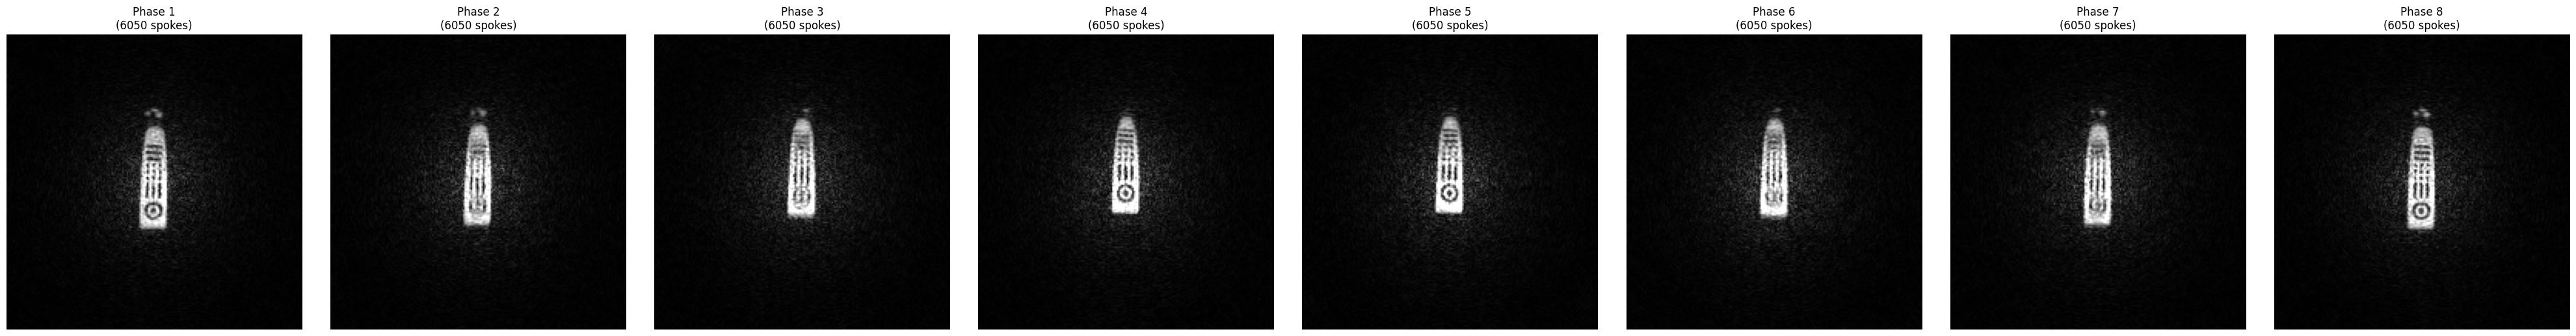

In [20]:
# This code reconstructs the 8 binned motion gates. It will therefore take several minutes to run.

phase_images = []
phase_titles = []

for i, mask in enumerate(phase_masks):

    data_bin = data_moving[..., mask]
    traj_bin = trajectory_moving[mask, :]

    print(f'Bin {i+1}: {np.sum(mask)} spokes')

    image = reconstruct_kooshball(
        data_bin,
        traj_bin
    )

    phase_images.append(image)
    phase_titles.append(
        f'Phase {i+1}\n({np.sum(mask)} spokes)'
    )

compare_image(phase_images, phase_titles)

By combining self-navigation, phase-portrait analysis and non-Cartesian image reconstruction, it is possible to retrospectively separate a single continuous acquisition into multiple motion-resolved image volumes representing different stages of the breathing cycle.

Such motion-resolved images can then be used to derive measurements of lung motion and lung function throughout the breathing cycle.

A reccomended starting point for further reading:

Barrau, N. 3D MR Spirometry. Signal and Image processing. Université Paris-Saclay, 2024. ⟨NNT: 2024UPAST077⟩. https://theses.hal.science/tel-04663088/

Lung function imaging at very low field:

1.  Senn N, et al. (2025) Feasibility of self-navigated motion resolved 3D lung
MRI on a non-commercial 100 mT system. ESMRMB 2025. https://doi.org/10.1007/s10334-025-01278-8 no. 461.
2.  Senn N, et al. (2026) Pulmonary ventilation mapping using a non-commercial very-low field MRI system. ISMRM 2026. http://echo.ismrm.org/abstracts/view/739c0d55-ae32-4416-8bef-d2695f4b85ac. no. 302-02-004.
3.  Senn N, et al. (2026) Free-breathing 4D lung imaging using a non-commercial very-low field MRI system. ISMRM 2026. http://echo.ismrm.org/abstracts/view/64e4754f-be0c-4fea-a398-685a88fee8fb no. 560-05-006.
